In [6]:
#ranking, match Score & full analysis
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import (
    build_restaurant_profiles, make_sample_dataset,
    preprocess_dataframe, get_tag_columns,
)
from ranking.match_score import parse_query, compute_match_scores, ablation_study
from evaluation.metrics import (
    plot_match_score_distribution, plot_score_breakdown,
)

sns.set_theme(style='whitegrid')
%matplotlib inline
os.makedirs('../data/figures', exist_ok=True)

In [7]:
#load restaurant profiles
try:
    profiles = pd.read_parquet('../data/restaurant_profiles.parquet')
    print(f'Loaded {len(profiles):,} restaurant profiles.')
except FileNotFoundError:
    print('Profiles not found — building from synthetic data.')
    df = preprocess_dataframe(make_sample_dataset(n=3000))
    profiles = build_restaurant_profiles(df)

profiles.head(3)

Loaded 6,463 restaurant profiles.


,business_id,avg_stars,review_count,name,city,state,categories,tag_quiet,tag_brunch,tag_date_night,tag_hidden_gem,tag_aesthetic,tag_family_friendly,tag_late_night,tag_trendy,n_negative,n_neutral,n_positive,positive_ratio
0,--ZVrH2X2QXBFdCilbirsw,4.735294,32,Chris's Sandwich Shop,Ardmore,PA,"American (Traditional), Restaurants, Pizza, Sa...",0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.117647,0,3,31,0.911765
1,--hF_3v1JmU9nlu4zfXJ8Q,4.777778,15,Green District Salads - Monument Circle,Indianapolis,IN,"Vegetarian, Restaurants, Wraps, Salad",0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.222222,0,0,9,1.000000
2,-0Ym1Wg3bXd_TDz8JtvOQg,4.405941,105,Yelo'd Ice Cream,Edmonton,AB,"Food, Ice Cream & Frozen Yogurt, Bakeries",0.0,0.059406,0.0,0.0,0.029703,0.009901,0.009901,0.099010,5,8,88,0.871287


In [8]:
#Ex query 1
QUERY_1 = 'Vegan brunch spots with a quiet, aesthetic vibe in Philadelphia'
parsed_1 = parse_query(QUERY_1)
print('Parsed query:', parsed_1)

results_1 = compute_match_scores(profiles, parsed_1, top_k=20)
print(f'\nTop {len(results_1)} results:')
display_cols = ['name', 'city', 'match_score', 'score_sentiment', 'score_tag_match', 'score_stars']
display_cols = [c for c in display_cols if c in results_1.columns]
results_1[display_cols].head(10)

Parsed query: {'raw_query': 'Vegan brunch spots with a quiet, aesthetic vibe in Philadelphia', 'tags': ['Quiet', 'Brunch', 'Aesthetic'], 'city': None, 'cuisine_keywords': ['vegan']}

Top 20 results:


,name,city,match_score,score_sentiment,score_tag_match,score_stars
0,Botanicals Nola,New Orleans,6.50,2.87,0.35,1.89
1,Algorithm Restaurants,Philadelphia,6.48,3.00,0.20,2.00
2,Grain and Berry,St. Petersburg,6.48,3.00,0.15,1.92
3,V-Trap Kitchen and Lounge,Wilmington,6.46,3.00,0.20,1.95
4,Red Hook Coffee & Tea,Philadelphia,6.45,2.70,0.36,1.77
5,LesbiVeggies,Audubon,6.44,2.65,0.51,1.80
6,KingCal Kitchen Meal Prep,Carmel,6.40,3.00,0.17,2.00
7,Sweet Soulfood,New Orleans,6.39,2.81,0.02,1.86
8,Oliver's,Santa Barbara,6.39,2.67,0.26,1.78
9,Franklin Juice Co,Franklin,6.31,2.82,0.18,1.82


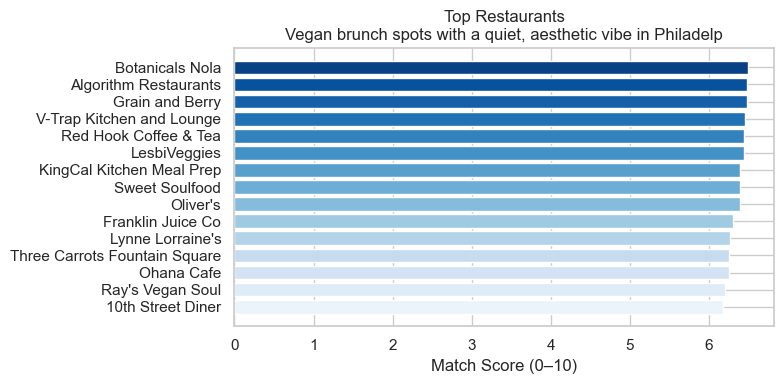

In [9]:
plot_match_score_distribution(
    results_1.head(15), query=QUERY_1,
    save_path='../data/figures/match_scores_q1.png'
);

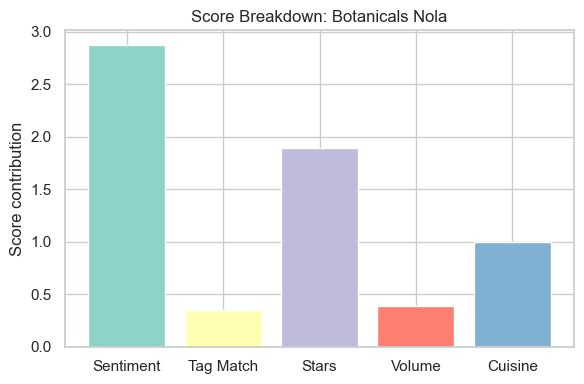

In [10]:
#s
#core breakdown for top result
plot_score_breakdown(results_1.iloc[0], save_path='../data/figures/score_breakdown_top1.png');

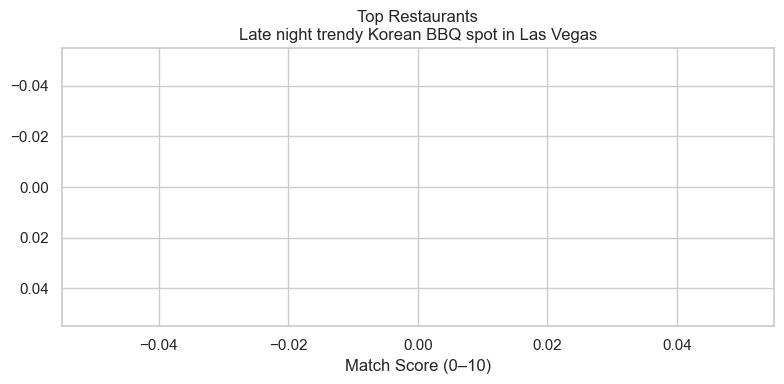

In [11]:
#Ex 2
QUERY_2 = 'Late night trendy Korean BBQ spot in Las Vegas'
parsed_2 = parse_query(QUERY_2)
results_2 = compute_match_scores(profiles, parsed_2, top_k=20)
plot_match_score_distribution(
    results_2.head(15), query=QUERY_2,
    save_path='../data/figures/match_scores_q2.png'
);

In [12]:
#ablation study
ablation_df = ablation_study(profiles, parsed_1)
print(ablation_df.pivot_table(index='rank', columns='ablation', values='match_score').round(2))

ablation  full  no_cuisine  no_sentiment  no_stars  no_tag_match  no_volume
rank                                                                       
1         6.50        6.11          5.41      5.86          9.11       6.89
2         6.48        6.09          5.35      5.79          9.03       6.85
3         6.48        6.09          5.31      5.78          8.98       6.83
4         6.46        6.07          5.23      5.76          8.95       6.79
5         6.45        6.06          5.23      5.76          8.90       6.75


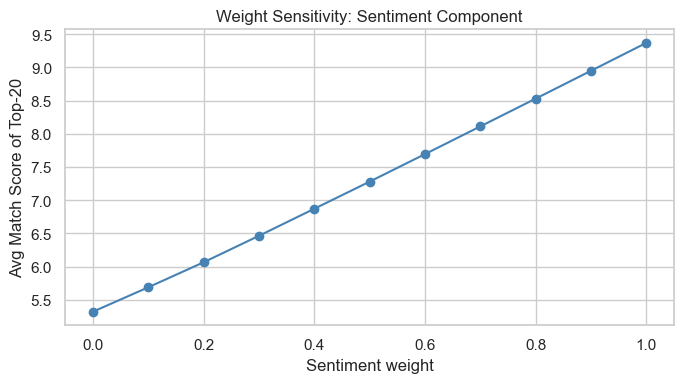

In [13]:
#weight sensitivity curves
weight_vals = np.linspace(0, 1, 11)
avg_scores = []
for w_sent in weight_vals:
    remaining = 1 - w_sent
    w = {
        'sentiment': w_sent,
        'tag_match': remaining * 0.4,
        'stars':     remaining * 0.3,
        'volume':    remaining * 0.15,
        'cuisine':   remaining * 0.15,
    }
    top = compute_match_scores(profiles, parsed_1, weights=w, top_k=20)
    avg_scores.append(top['match_score'].mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(weight_vals, avg_scores, marker='o', color='steelblue')
ax.set_xlabel('Sentiment weight')
ax.set_ylabel('Avg Match Score of Top-20')
ax.set_title('Weight Sensitivity: Sentiment Component')
plt.tight_layout()
plt.savefig('../data/figures/weight_sensitivity.png', dpi=150)
plt.show()

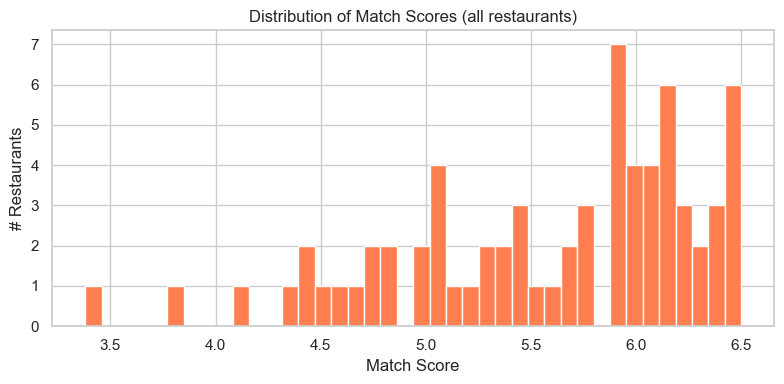

In [14]:
#scores distribution
all_results = compute_match_scores(profiles, parsed_1, top_k=len(profiles))
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_results['match_score'], bins=40, color='coral', edgecolor='white')
ax.set_xlabel('Match Score')
ax.set_ylabel('# Restaurants')
ax.set_title('Distribution of Match Scores (all restaurants)')
plt.tight_layout()
plt.savefig('../data/figures/score_distribution.png', dpi=150)
plt.show()